In [27]:
import pandas as pd

In [28]:
data = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv')

In [29]:
data

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [30]:
data.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [31]:
data.columns = data.columns.str.lower().str.replace(' ', '_')

In [32]:
strings = list(data.dtypes[data.dtypes == 'object'].index)
strings

[]

In [33]:
# Identify current text columns and cast them to object
string_cols = data.select_dtypes(include=['string', 'object']).columns
data[string_cols] = data[string_cols].astype(object)



In [34]:
for col in strings:
    data[col].str.lower().str.replace(' ', '_')
    

In [35]:
# 1. Identify all columns that have an 'object' data type
object_cols = data.select_dtypes(include=['object']).columns

# 2. Loop through each object column and format its text content
for col in object_cols:
    data[col] = data[col].str.lower().str.replace(' ', '_')


In [36]:
data.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [37]:
for col in data.columns:
    print(col)
    print(data[col].unique())
    print(data[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler' 'nissan' 'volvo' 'mazda'
 'mitsubishi' 'ferrari' 'alfa_romeo' 'toyota' 'mclaren' 'maybach'
 'pontiac' 'porsche' 'saab' 'gmc' 'hyundai' 'plymouth' 'honda'
 'oldsmobile' 'suzuki' 'ford' 'cadillac' 'kia' 'bentley' 'chevrolet'
 'dodge' 'lamborghini' 'lincoln' 'subaru' 'volkswagen' 'spyker' 'buick'
 'acura' 'rolls-royce' 'maserati' 'lexus' 'aston_martin' 'land_rover'
 'lotus' 'infiniti' 'scion' 'genesis' 'hummer' 'tesla' 'bugatti']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class' '2_series' '200'
 '200sx' '240sx' '240' '2' '3_series_gran_turismo' '3_series' '300-class'
 '3000gt' '300' '300m' '300zx' '323' '350-class' '350z' '360' '370z' '3'
 '4_series_gran_coupe' '4_series' '400-class' '420-class' '456m'
 '458_italia' '4c' '4runner' '5_series_gran_turismo' '5_series'
 '500-class' '500e' '500' '500l' '500x' '550' '560-class' '570s' '575m'
 '57' '599' '5' '6_series_gran_coupe' '6_series' '600-class' '6000'
 '612_scaglietti'

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 

<Axes: xlabel='msrp', ylabel='Count'>

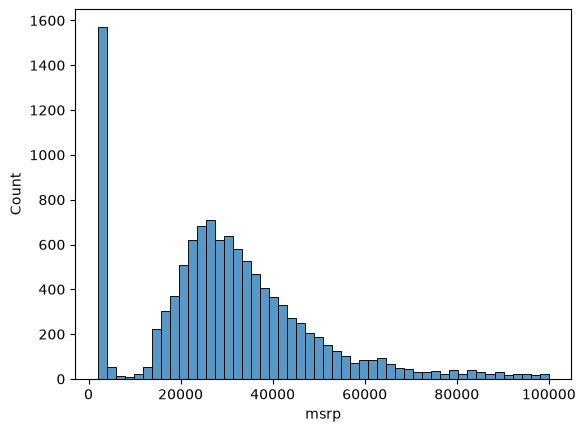

In [39]:
sns.histplot(data.msrp[data.msrp < 100000], bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

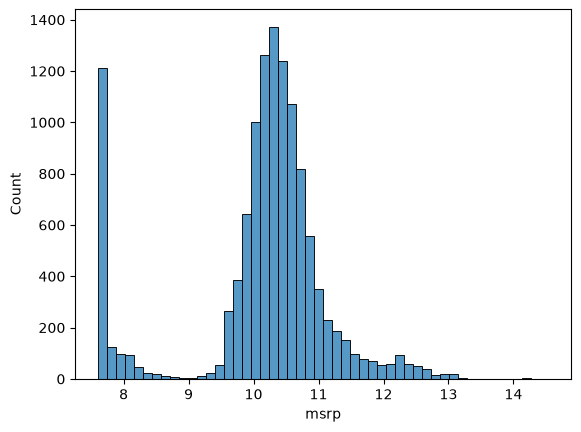

In [40]:
import numpy as np
price_logs = np.log1p(data.msrp)

sns.histplot(price_logs, bins=50)

In [41]:
data.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [42]:
n = len(data)
n_val = int(n* 0.2)
n_test = int(n* 0.2)
n_train = n - n_val - n_test

n, n_train, n_test, n_val

(11914, 7150, 2382, 2382)

In [43]:
df_train = data.iloc[n_train:]
df_val = data.iloc[n_train:n_train + n_val]
df_test = data.iloc[n_train + n_val:]

idx = np.arange(n)

np.random.shuffle(idx)


In [44]:
data.iloc[idx[n_train:]]

df_train = data.iloc[idx[:n_train]]
df_val = data.iloc[idx[n_train:n_train + n_val]]
df_test = data.iloc[idx[n_train + n_val:]]

df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2731,mercedes-benz,cls-class,2016,premium_unleaded_(required),402.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,high-performance",midsize,sedan,26,17,617,74100
5614,volkswagen,gti,2012,premium_unleaded_(recommended),200.0,4.0,manual,front_wheel_drive,4.0,"hatchback,performance",compact,4dr_hatchback,31,21,873,28445
6652,chevrolet,malibu_classic,2008,regular_unleaded,219.0,6.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,29,18,1385,19695
6653,chevrolet,malibu_hybrid,2008,regular_unleaded,164.0,4.0,automatic,front_wheel_drive,4.0,hybrid,midsize,sedan,32,24,1385,23640
7183,plymouth,neon,1999,regular_unleaded,150.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,36,24,535,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8584,nissan,rogue,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,33,26,2009,24780
5361,volkswagen,golf_alltrack,2017,regular_unleaded,170.0,4.0,automated_manual,all_wheel_drive,4.0,crossover,compact,wagon,30,22,873,30530
3619,dodge,durango,2016,regular_unleaded,293.0,6.0,automatic,all_wheel_drive,4.0,crossover,large,4dr_suv,25,18,1851,39595
11461,subaru,wrx,2016,premium_unleaded_(recommended),268.0,4.0,manual,all_wheel_drive,4.0,performance,compact,sedan,27,20,640,28895


In [45]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [46]:
df_train=df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train

df_val

df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,ford,f-250,1997,regular_unleaded,220.0,8.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,17,12,5657,3008
1,volkswagen,eurovan,2003,premium_unleaded_(recommended),201.0,6.0,automatic,front_wheel_drive,3.0,NaN,large,passenger_minivan,18,15,873,26200
2,buick,lucerne,2010,flex-fuel_(unleaded/e85),227.0,6.0,automatic,front_wheel_drive,4.0,flex_fuel,large,sedan,26,17,155,34830
3,toyota,tundra,2015,flex-fuel_(unleaded/e85),381.0,8.0,automatic,four_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,17,13,2031,32170
4,volkswagen,jetta_gli,2014,premium_unleaded_(recommended),210.0,4.0,manual,front_wheel_drive,4.0,performance,midsize,sedan,33,23,873,24535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,land_rover,range_rover_sport,2014,premium_unleaded_(required),510.0,8.0,automatic,four_wheel_drive,4.0,"luxury,high-performance",midsize,4dr_suv,19,14,258,92400
2378,chevrolet,astro_cargo,2004,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,3.0,NaN,large,cargo_minivan,19,14,1385,22695
2379,aston_martin,v8_vantage,2015,premium_unleaded_(required),430.0,8.0,automated_manual,rear_wheel_drive,2.0,"exotic,high-performance",compact,convertible,21,14,259,118400
2380,toyota,previa,1995,regular_unleaded,161.0,4.0,automatic,all_wheel_drive,3.0,NaN,compact,passenger_minivan,20,15,2031,2000


In [47]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [48]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [49]:
len(y_train)

7150